# Results

In [43]:
import torch
from sklearn.metrics import ndcg_score

def __kl_divergence(p, q):
    """
    Calculate KL-Divergence between P and Q, with epsilon to avoid divide by zero.
    :param p: PyTorch tensor p distribution.
    :param q: PyTorch tensor q distribution.
    :return: KL-Divergence score.
    """
    epsilon = 1e-7  # Epsilon is used here to avoid P or Q is equal to 0.
    p = p + epsilon
    q = q + epsilon

    return torch.sum(p * torch.log(p / q))

def NDKL(ranking, item_group_dict):
    """
    Calculate Normalized Discounted KL-Divergence Score (Geyik et al.).
    :param ranking: PyTorch tensor of ranking(s).
    :param item_group_dict: Dictionary of items (keys) and their group membership (values).
    :return: NDKL value.
    """
    if ranking.dim() > 1:
        raise AssertionError("NDKL can only be calculated on a single ranking.")

    single_ranking = ranking.squeeze()  # ensure 1D tensor
    single_ranking = single_ranking[~torch.isnan(single_ranking)]  # drop any NaNs

    group_ids = torch.tensor([item_group_dict[c.item()] for c in single_ranking])
    unique_grps = torch.unique(group_ids)
    group_ids = torch.tensor([torch.where(unique_grps == grp_of_item)[0][0] for grp_of_item in group_ids])
    num_groups = group_ids.max().item()
    num_items = len(group_ids)

    dr = __distributions(group_ids, num_groups)  # Distributions per group
    Z = __Z_Vector(num_items)  # Array of Z scores

    # Eq. 4 in Geyik et al.
    return (1 / Z.sum()) * sum(
        Z[i] * __kl_divergence(__distributions(group_ids[:i+1], num_groups), dr)
        for i in range(num_items)
    )

def __distributions(ranking, num_groups):
    """
    Calculate the proportion of each group
    :param ranking: PyTorch tensor of group id represented in the ranking.
    :param num_groups: Int, number of distinct groups
    :return: PyTorch tensor of each group's proportion.
    """
    return torch.tensor([(ranking == i).sum() / len(ranking) for i in range(num_groups + 1)])

def __Z_Vector(k):
    """
    Calculate Z score
    :param k: Int, position of ranking.
    :return: PyTorch tensor of Z values.
    """
    return 1 / torch.log2(torch.arange(k, dtype=torch.float) + 2)

In [44]:
import numpy as np
import pandas as pd

# Script to calculate NDKL metric
# References: Geyik, S. C., Ambler, S., & Kenthapadi, K. (2019, July).
# Fairness-aware ranking in search & recommendation systems with application to linkedin talent search.
# In Proceedings of the 25th acm sigkdd international conference on knowledge discovery & data mining (pp. 2221-2231).


def __kl_divergence(p, q):
    """
    Calculate KL-Divergence between P and Q, with epsilon to avoid divide by zero.
    :param p: Numpy array p distribution.
    :param q: Numpy array q distribution.
    :return: KL-Divergence score.
    """
    epsilon = 0.0000001  # Epsilon is used here to avoid P or Q is equal to 0. "
    p = p + epsilon
    q = q + epsilon

    return np.sum(p * np.log(p / q))


def NDKL(ranking_df, item_group_dict):
    """
    Calculate Normalized Discounted KL-Divergence Score (Geyik et al.).
    :param ranking_df: Pandas dataframe of ranking(s).
    :param item_group_dict: Dictionary of items (keys) and their group membership (values).
    :return: NDKL value.
    """
    if len(ranking_df.columns) > 1:
        raise AssertionError("NDKL can only be calculated on a single ranking.")

    single_ranking = ranking_df[ranking_df.columns[0]]  # isolate ranking
    single_ranking = np.array(
        single_ranking[~pd.isnull(single_ranking)]
    )  # drop any NaNs

    group_ids = [item_group_dict[c] for c in single_ranking]
    unique_grps = np.unique(group_ids)
    group_ids = np.asarray(
        [np.argwhere(unique_grps == grp_of_item)[0, 0] for grp_of_item in group_ids]
    )
    num_groups = np.max(group_ids)
    num_items = len(group_ids)

    dr = __distributions(group_ids, num_groups)  # Distributions per group
    Z = __Z_Vector(num_items)  # Array of Z scores

    # Eq. 4 in Geyik et al.
    return (1 / np.sum(Z)) * np.sum(
        [
            Z[i]
            * __kl_divergence(__distributions(group_ids[0 : i + 1], num_groups), dr)
            for i in range(0, num_items)
        ]
    )


def __distributions(ranking, num_groups):
    """
    Calculate the proportion of each group
    :param ranking: Numpy array of group id represented in the ranking.
    :param num_groups: Int, number of distinct groups
    :return: Numpy array of each group's proportion.
    """
    return np.array(
        [((ranking == i).sum()) / len(ranking) for i in range(0, num_groups + 1)]
    )


def __Z_Vector(k):
    """
    Calculate Z score
    :param k: Int, position of ranking.
    :return: Numpy array of Z values.
    """
    return 1 / np.log2(np.array(range(0, k)) + 2)


In [45]:
import pandas
import torch
import numpy as np
import torch
from torchmetrics.functional.retrieval import retrieval_hit_rate, retrieval_precision
import torch.nn.functional as F

def fair_metric(pred, labels, sens):
    idx_s0 = sens == 0
    idx_s1 = sens == 1
    idx_s0_y1 = np.bitwise_and(idx_s0, labels == 1)
    idx_s1_y1 = np.bitwise_and(idx_s1, labels == 1)
    parity = abs(sum(pred[idx_s0]) / sum(idx_s0) - sum(pred[idx_s1]) / sum(idx_s1))
    equality = abs(
        sum(pred[idx_s0_y1]) / sum(idx_s0_y1) - sum(pred[idx_s1_y1]) / sum(idx_s1_y1)
    )
    return parity.item(), equality.item()


def eval_hits(y_pred_pos, y_pred_neg, K, type_info):
        '''
            compute Hits@K
            For each positive target node, the negative target nodes are the same.

            y_pred_neg is an array.
            rank y_pred_pos[i] against y_pred_neg for each i
        '''

        if len(y_pred_neg) < K:
            return {'hits@{}'.format(K): 1.}

        if type_info == 'torch':
            kth_score_in_negative_edges = torch.topk(y_pred_neg, K)[0][-1]
            hitsK = float(torch.sum(y_pred_pos > kth_score_in_negative_edges).cpu()) / len(y_pred_pos)

        # type_info is numpy
        else:
            kth_score_in_negative_edges = np.sort(y_pred_neg)[-K]
            hitsK = float(np.sum(y_pred_pos > kth_score_in_negative_edges)) / len(y_pred_pos)

        return {'hits@{}'.format(K): hitsK}
    
    
def fairness_aware_topk(outputs, K, sens, type_info):
        '''
            compute Hits@K
            For each positive target node, the negative target nodes are the same.

            y_pred_neg is an array.
            rank y_pred_pos[i] against y_pred_neg for each i
        '''
        
        sens_stats = F.one_hot(sens, 2).float().sum(0) / len(sens)
        

        if len(outputs) < K:
            return {'hits@{}'.format(K): 1.}

        if type_info == 'torch':
            top_k = torch.topk(outputs, K).indices
            top_k_stats = F.one_hot(sens[top_k], 2).float().sum(0) / K
            sens_diff = torch.abs(top_k_stats - sens_stats).sum().item()
        else:
            top_k = np.argsort(outputs)[-K:]
            top_k_stats = F.one_hot(sens[top_k], 2).float().sum(0) / K
            sens_diff = np.abs(top_k_stats - sens_stats).sum()

        return sens_diff

    
def fairness_aware_hits(y_pred_pos, y_pred_neg, K, sens_pos, type_info):
        '''
            compute Hits@K
            For each positive target node, the negative target nodes are the same.

            y_pred_neg is an array.
            rank y_pred_pos[i] against y_pred_neg for each i
        '''
        
        sens_stats = F.one_hot(sens_pos, 2).float().sum(0) / len(sens_pos)
        

        if len(y_pred_neg) < K:
            return {'hits@{}'.format(K): 1.}

        if type_info == 'torch':
            
            kth_score_in_negative_edges = torch.topk(y_pred_neg, K)[0][-1]
            sens_pos_in_top_k = sens_pos[y_pred_pos > kth_score_in_negative_edges]
            sens_in_hits_at_k_stats = F.one_hot(sens_pos_in_top_k, 2).float().sum(0) / len(sens_pos_in_top_k)
            sens_diff = torch.abs(sens_in_hits_at_k_stats - sens_stats).sum().item()
        
        # type_info is numpy
        else:
            kth_score_in_negative_edges = np.sort(y_pred_neg)[-K]
            sens_pos_in_top_k = sens_pos[y_pred_pos > kth_score_in_negative_edges]
            sens_in_hits_at_k_stats = F.one_hot(sens_pos_in_top_k, 2).float().sum(0) / len(sens_pos_in_top_k)
            sens_diff = np.abs(sens_in_hits_at_k_stats - sens_stats).sum()

        return sens_diff
    
    
    
def edge_cosine_similarity(embeddings, edge_index):
    '''
        Compute the cosine similarity of the embeddings of the edges
    '''
    src, dst = edge_index
    src_emb = embeddings[src, :]
    dst_emb = embeddings[dst, :]
    cosine_similarity = torch.nn.functional.cosine_similarity(src_emb, dst_emb)
    return cosine_similarity


import matplotlib.pyplot as plt
import itertools
import random

def plot_coordinates(coords, labels=None, x_axis_label='X coordinate', y_axis_label='Y coordinate', title='Comparison of Different Methods'):
    def process_styles(labels):
        fair_model_styles = {
            'NIFTY' : 'D',
            'FairGNN': 'D',
            'FairVGNN': 'D',
            'GRAPHAIR': 'o',
            'EDITS': 's'
        }
        
        model_styles = {
            'GAE' : 'r',
            'NCN' : 'b',
            'SEAL' : 'g',
        }
        
        split_label_names = map(lambda x: x.split('_'), labels)
        
        for split_label in split_label_names:
            if len(split_label) != 2:
                raise ValueError("Labels must be in the format 'model_fairness'")
        
        return list(map(lambda x: (fair_model_styles[x[0]], model_styles[x[1]]), split_label_names))
        
        
    
    random.seed(42)

    try:
        styles = process_styles(labels)
    except Exception as e:
        print("Failed processing styles", e)
        # Available markers (symbols) for plotting
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '1', '2', '3', '4', '8']
        colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
        
        # Create combinations of markers and colors
        styles = list(itertools.product(markers, colors))
        random.shuffle(styles)
    
    # If labels are not provided, use default labels
    if labels is None:
        labels = [f'Method {i+1}' for i in range(len(coords))]
    
    # Ensure we have the same number of labels as coordinates
    if len(labels) != len(coords):
        raise ValueError("The number of labels must match the number of coordinate pairs.")
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Plot each coordinate pair with a unique symbol and label
    for (x, y), label, style in zip(coords, labels, styles):
        marker, color = style
        plt.plot(x, y, marker=marker, color=color, markersize=10, label=label, linestyle='None')
    
    # Add labels and title
    plt.xlabel(x_axis_label)
    plt.ylabel(y_axis_label)
    plt.title(title)
    
    # Add a legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Display the grid
    plt.grid(True)
    
    # Adjust layout to prevent clipping of tick-labels
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    

In [46]:
stats = {}

## EDITS - GAE

In [47]:
stats['EDITS_GAE'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    try:

        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt', map_location=torch.device('cpu'))
        output = torch.load(f"/home/jrm28/fairness/pre_processing_methods/processed_graphs/{dataset}_EDITSTRAINED_GAE.pt", map_location=torch.device('cpu'))

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()

        parity, equality = fair_metric(output.sigmoid().detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        fair_topk = fairness_aware_topk(output.squeeze(), 100, sens, 'torch')
        fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()].squeeze(), output.detach()[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')

        y_pred_pos = output.detach().numpy()[labels.bool()]
        y_pred_neg = output.detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output.sigmoid().squeeze(), labels.bool(), 100).item()
        
        ndkl = NDKL(pd.DataFrame(output.sigmoid().squeeze().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
        
        
        stats['EDITS_GAE'][dataset] = {}
        stats['EDITS_GAE'][dataset]['parity'] = parity
        stats['EDITS_GAE'][dataset]['equality'] = equality
        stats['EDITS_GAE'][dataset]['fair_topk'] = fair_topk
        stats['EDITS_GAE'][dataset]['fair_hitsk'] = fair_hitsk
        stats['EDITS_GAE'][dataset] |= hits
        stats['EDITS_GAE'][dataset]['precision'] = precision
        stats['EDITS_GAE'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
    
    except FileNotFoundError:
        print(dataset, "not found")


/tmp/ipykernel_2158402/1128921596.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()].squeeze(), output.detach()[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.013632923364639282 0.05424684286117554 {'hits@100': 0.56608711908768} 0.9900000095367432 0.002037203368856111
credit 0.0036129634191706117 0.0013118453933520513 {'hits@100': 0.0} 1.0 0.0005336702458851088
german 0.015585154294967651 0.017145812511444092 {'hits@100': 0.21803127874885003} 1.0 0.0072172130177945585
nba 0.0005099475383758545 0.0012787282466888428 {'hits@100': 0.5677966101694916} 0.46000000834465027 0.003346071820700047
pokec_n not found
pokec_z not found


## EDITS - NCN

In [48]:
stats['EDITS_NCN'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    try:

        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt', map_location=torch.device('cpu'))
        output = torch.load(f"/home/jrm28/fairness/pre_processing_methods/processed_graphs/{dataset}_EDITSTRAINED_NCN.pt", map_location=torch.device('cpu'))

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()
        
        output = output.sigmoid()

        parity, equality = fair_metric(output.detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        fair_topk = fairness_aware_topk(output.squeeze(), 100, sens, 'torch')
        fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()].squeeze(), output.detach()[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')

        y_pred_pos = output.detach().numpy()[labels.bool()]
        y_pred_neg = output.detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output.squeeze(), labels.bool(), 100).item()
        
        ndkl = NDKL(pd.DataFrame(output.sigmoid().squeeze().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
        
        
        stats['EDITS_NCN'][dataset] = {}
        stats['EDITS_NCN'][dataset]['parity'] = parity
        stats['EDITS_NCN'][dataset]['equality'] = equality
        stats['EDITS_NCN'][dataset]['equality'] = equality
        stats['EDITS_NCN'][dataset]['fair_topk'] = fair_topk
        stats['EDITS_NCN'][dataset]['fair_hitsk'] = fair_hitsk
        stats['EDITS_NCN'][dataset] |= hits
        stats['EDITS_NCN'][dataset]['precision'] = precision
        stats['EDITS_NCN'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
    
    except FileNotFoundError:
        print(dataset, "not found")


/tmp/ipykernel_2158402/492469529.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()].squeeze(), output.detach()[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.0028978586196899414 0.015920519828796387 {'hits@100': 0.5726303982052721} 0.9800000190734863 0.0009688312706231798
credit 0.1311347335577011 0.23620542883872986 {'hits@100': 0.4036760691537762} 1.0 0.0034789827352862466
german 0.026284098625183105 0.009054481983184814 {'hits@100': 0.0} 1.0 0.009330391643815937
nba 0.009425848722457886 0.014232546091079712 {'hits@100': 0.4114877589453861} 0.6399999856948853 0.01581787044897832
pokec_n not found
pokec_z not found


## FairWalk

import os

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    # file_name = next(filter(lambda x: f'GRAPHAIR_{dataset}' in x, os.listdir('/home/jrm28/fairness/pre_processing_methods/processed_graphs/')))

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt', map_location=torch.device('cpu'))
    output = torch.load(f"/home/jrm28/fairness/node_embeddings_methods/processed_graphs/{dataset}_FAIR_WALK.pt", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()
    
    
    output = edge_cosine_similarity(torch.tensor(output), test_edges.t()).sigmoid().numpy()

    parity, equality = fair_metric(output, labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(torch.tensor(output).squeeze(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(torch.tensor(output)[labels.bool()].squeeze(), torch.tensor(output)[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[labels.bool()]
    y_pred_neg = output[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    
    
    stats['GRAPHAIR'][dataset] = {}
    stats['GRAPHAIR'][dataset]['parity'] = parity
    stats['GRAPHAIR'][dataset]['equality'] = equality
    stats['GRAPHAIR'][dataset]['fair_topk'] = fair_topk
    stats['GRAPHAIR'][dataset]['fair_hitsk'] = fair_hitsk
    stats['GRAPHAIR'][dataset] |= hits

    print(dataset, parity, equality, hits)


## GraphAIR

In [49]:
stats['GRAPHAIR'] = {}

In [50]:
import os

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    file_name = next(filter(lambda x: f'GRAPHAIR_{dataset}' in x, os.listdir('/home/jrm28/fairness/pre_processing_methods/processed_graphs/')))

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt', map_location=torch.device('cpu'))
    output = torch.load(f"/home/jrm28/fairness/pre_processing_methods/processed_graphs/{file_name}", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()
    
    
    output = edge_cosine_similarity(output[2], test_edges.t()).sigmoid().numpy()

    parity, equality = fair_metric(output, labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(torch.tensor(output).squeeze(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(torch.tensor(output)[labels.bool()].squeeze(), torch.tensor(output)[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[labels.bool()]
    y_pred_neg = output[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    precision = retrieval_precision(torch.tensor(output).squeeze(), labels.bool(), 100).item()
    
    ndkl = NDKL(pd.DataFrame(torch.tensor(output).squeeze().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
    
    
    stats['GRAPHAIR'][dataset] = {}
    stats['GRAPHAIR'][dataset]['parity'] = parity
    stats['GRAPHAIR'][dataset]['equality'] = equality
    stats['GRAPHAIR'][dataset]['fair_topk'] = fair_topk
    stats['GRAPHAIR'][dataset]['fair_hitsk'] = fair_hitsk
    stats['GRAPHAIR'][dataset] |= hits
    stats['GRAPHAIR'][dataset]['precision'] = precision
    stats['GRAPHAIR'][dataset]['ndkl'] = ndkl

    print(dataset, parity, equality, hits)
    


/tmp/ipykernel_2158402/1232035820.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(torch.tensor(output)[labels.bool()].squeeze(), torch.tensor(output)[~labels.bool()].squeeze(), 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.0011977398265554662 0.0033874898288313027 {'hits@100': 0.4010095344924285}
credit 0.0012057237546889699 0.001562532668303862 {'hits@100': 0.28305732484076435}
german 8.142763469831671e-05 7.901319156777831e-05 {'hits@100': 0.08509659613615456}
nba 1.66843709858977e-06 0.00020187806029192679 {'hits@100': 0.1337099811676083}
pokec_n 0.0058632544557833954 0.00327088840345624 {'hits@100': 0.03374948021932327}
pokec_z 0.007895921595586053 0.004360691163631802 {'hits@100': 0.04368441067715287}


## DELTR - GAE

In [51]:
stats['DELTR_GAE'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    try:
        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
        output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_DELTR_GAE.pt", map_location=torch.device('cpu'))
        
        output = output.sigmoid().squeeze()

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()

        parity, equality = fair_metric(output.detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        fair_topk = fairness_aware_topk(output.detach(), 100, sens, 'torch')
        fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()], output.detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

        y_pred_pos = output.detach().numpy()[labels.bool()]
        y_pred_neg = output.detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output, labels.bool(), 100).item()
        ndkl = NDKL(pd.DataFrame(output.detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
        
        
        stats['DELTR_GAE'][dataset] = {}
        stats['DELTR_GAE'][dataset]['parity'] = parity
        stats['DELTR_GAE'][dataset]['equality'] = equality
        stats['DELTR_GAE'][dataset]['fair_topk'] = fair_topk
        stats['DELTR_GAE'][dataset]['fair_hitsk'] = fair_hitsk
        stats['DELTR_GAE'][dataset] |= hits
        stats['DELTR_GAE'][dataset]['precision'] = precision
        stats['DELTR_GAE'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
    except FileNotFoundError:
        print(dataset, "not found")

/tmp/ipykernel_2158402/3561365786.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()], output.detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.005303027370036295 0.011117867341277843 {'hits@100': 0.3690409422321929} 1.0 0.003990020342449242
credit 0.007155000800584732 0.013780803188235047 {'hits@100': 0.28786169244767973} 0.9900000095367432 0.0019745403015741896
german 0.0 0.0 {'hits@100': 0.0} 1.0 0.020981371275551906
nba 0.05814159860438217 0.05805912476746222 {'hits@100': 0.0} 0.41999998688697815 0.04604648390614245
pokec_n 0.1606021890152145 0.1352439588735208 {'hits@100': 0.00020307710160624316} 0.20000000298023224 0.19673432244292546
pokec_z 0.14432315185482258 0.12939707875891626 {'hits@100': 3.236481620829996e-05} 0.03999999910593033 0.20779557821234432


## DELTR - NCN

In [52]:
stats['DELTR_NCN'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    try:

        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
        output  = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_DELTR_NCN.pt", map_location=torch.device('cpu'))
        
        output = output.squeeze()

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()

        parity, equality = fair_metric(output.detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        # fair_topk = fairness_aware_topk(output.detach(), 100, sens, 'torch')
        # fair_hitsk = fairness_aware_hits(output.detach()[labels.bool()], output.detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

        y_pred_pos = output.detach().numpy()[labels.bool()]
        y_pred_neg = output.detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output, labels.bool(), 100).item()
        ndkl = NDKL(pd.DataFrame(output.detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
        
        
        stats['DELTR_NCN'][dataset] = {}
        stats['DELTR_NCN'][dataset]['parity'] = parity
        stats['DELTR_NCN'][dataset]['equality'] = equality
        # stats['DELTR_NCN'][dataset]['fair_topk'] = fair_topk
        # stats['DELTR_NCN'][dataset]['fair_hitsk'] = fair_hitsk
        stats['DELTR_NCN'][dataset] |= hits
        stats['DELTR_NCN'][dataset]['precision'] = precision
        stats['DELTR_NCN'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
    
        
    except FileNotFoundError:
        print(dataset, "not found")


facebook 0.005642683549134442 0.01570940242735641 {'hits@100': 0.3892316320807628} 1.0 0.003373296124816444
credit 0.004971254828333643 0.008909938817443607 {'hits@100': 0.0} 0.0 0.002138989108871394
german 0.18719325031087303 0.020420972309544178 {'hits@100': 0.0} 1.0 0.011180350278826577
nba 0.25907297040669236 0.2608536342689385 {'hits@100': 0.0} 0.550000011920929 0.0332529735943881
pokec_n 0.7186362346856545 0.550126298443845 {'hits@100': 0.00023208811612142078} 0.20999999344348907 0.19552181969814392
pokec_z 0.8183040513766059 0.6946293174206691 {'hits@100': 0.00012136806078112484} 0.12999999523162842 0.20748226376777437


## NIFTY - GAE

In [53]:
stats['NIFTY_GAE'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
    output, counter_output, noisy_output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_NIFTY_GAE.pt", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()

    parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
    y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
    ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
    
    
    stats['NIFTY_GAE'][dataset] = {}
    stats['NIFTY_GAE'][dataset]['parity'] = parity
    stats['NIFTY_GAE'][dataset]['equality'] = equality
    stats['NIFTY_GAE'][dataset]['fair_topk'] = fair_topk
    stats['NIFTY_GAE'][dataset]['fair_hitsk'] = fair_hitsk
    stats['NIFTY_GAE'][dataset] |= hits
    stats['NIFTY_GAE'][dataset]['precision'] = precision
    stats['NIFTY_GAE'][dataset]['ndkl'] = ndkl

    print(dataset, parity, equality, hits, precision, ndkl)


/tmp/ipykernel_2158402/770818999.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.0002387374873455972 0.00040641682282538394 {'hits@100': 0.011030099083940923} 0.4099999964237213 0.004332142372731082
credit 0.002469100981239203 0.0059087212775690845 {'hits@100': 0.0013830755232029117} 1.0 0.0012562168287573686
german 0.0004258034288692758 0.0017575228143307808 {'hits@100': 0.0027598896044158236} 0.9100000262260437 0.019769672446354133
nba 0.0012636008212510985 0.0008942924473143155 {'hits@100': 0.006591337099811676} 0.12999999523162842 0.0046506710572788365
pokec_n 0.14408860665880102 0.09013469917034661 {'hits@100': 0.03350772176503012} 0.9900000095367432 0.0208861727859249
pokec_z 0.059087466951363576 0.031923133111904256 {'hits@100': 0.01212871487406041} 0.9599999785423279 0.022778454013355078


## NIFTY - NCN

In [54]:
stats['NIFTY_NCN'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
    output, counter_output, noisy_output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_NIFTY_NCN.pt", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()

    parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
    y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
    ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
    
    
    stats['NIFTY_NCN'][dataset] = {}
    stats['NIFTY_NCN'][dataset]['parity'] = parity
    stats['NIFTY_NCN'][dataset]['equality'] = equality
    stats['NIFTY_NCN'][dataset]['fair_topk'] = fair_topk
    stats['NIFTY_NCN'][dataset]['fair_hitsk'] = fair_hitsk
    stats['NIFTY_NCN'][dataset] |= hits
    stats['NIFTY_NCN'][dataset]['precision'] = precision
    stats['NIFTY_NCN'][dataset]['ndkl'] = ndkl

    print(dataset, parity, equality, hits, precision, ndkl)


/tmp/ipykernel_2158402/3687840394.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.010727710776606003 0.011375944954693629 {'hits@100': 0.5219667227519162} 1.0 0.0020108379766531426
credit 0.08292569708035624 0.1334672459000597 {'hits@100': 0.3396542311191993} 1.0 0.0011243808683411881
german 0.12280797679341171 0.01380274314126595 {'hits@100': 0.2748390064397424} 1.0 0.013572755502233835
nba 0.030098769653477853 0.011909205866748318 {'hits@100': 0.2066854990583804} 0.9300000071525574 0.005331806729855154
pokec_n 0.16847660829576086 0.1321201315034165 {'hits@100': 0.23046349930857082} 1.0 0.023652868997048514
pokec_z 0.20475680766065016 0.1545168055075083 {'hits@100': 0.18858978404576385} 1.0 0.03144213170340895


## FairGNN - GAE

In [55]:
stats['FairGNN_GAE'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
    output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_FAIR_GNN_GAE.pt", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()

    parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
    y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
    ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
    
    
    stats['FairGNN_GAE'][dataset] = {}
    stats['FairGNN_GAE'][dataset]['parity'] = parity
    stats['FairGNN_GAE'][dataset]['equality'] = equality
    stats['FairGNN_GAE'][dataset]['fair_topk'] = fair_topk
    stats['FairGNN_GAE'][dataset]['fair_hitsk'] = fair_hitsk
    stats['FairGNN_GAE'][dataset] |= hits
    stats['FairGNN_GAE'][dataset]['precision'] = precision
    stats['FairGNN_GAE'][dataset]['ndkl'] = ndkl

    print(dataset, parity, equality, hits, precision, ndkl)


/tmp/ipykernel_2158402/2344404982.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.02919594210372478 0.05776066237100097 {'hits@100': 0.4997195737521032} 1.0 0.008021215451919077
credit 0.03065557286676568 0.029937311915930076 {'hits@100': 0.029044585987261146} 1.0 0.0013101582736150103
german 0.0 0.0 {'hits@100': 0.05197792088316467} 1.0 0.020981371275551906
nba 3.576443321660462e-05 9.32772151584792e-05 {'hits@100': 0.005178907721280603} 0.09000000357627869 0.0015374610160035446
pokec_n 0.22264513691698135 0.10123449022871472 {'hits@100': 0.058437853571739404} 1.0 0.0325722552962765
pokec_z 0.3054680021306301 0.15163635937859032 {'hits@100': 0.0544780768826209} 0.9800000190734863 0.0431580726104843


## FairGNN - NCN

In [56]:
stats['FairGNN_NCN'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:

    data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
    output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_FAIR_GNN_NCN.pt", map_location=torch.device('cpu'))

    test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
    labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
    sens = (data.y[test_edges].sum(1) == 1).long()

    parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
    parity, equality
    
    fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
    fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

    y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
    y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
    hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
    precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
    ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
    

    stats['FairGNN_NCN'][dataset] = {}
    stats['FairGNN_NCN'][dataset]['parity'] = parity
    stats['FairGNN_NCN'][dataset]['equality'] = equality
    stats['FairGNN_NCN'][dataset]['fair_topk'] = fair_topk
    stats['FairGNN_NCN'][dataset]['fair_hitsk'] = fair_hitsk
    stats['FairGNN_NCN'][dataset] |= hits
    stats['FairGNN_NCN'][dataset]['precision'] = precision
    stats['FairGNN_NCN'][dataset]['ndkl'] = ndkl

    print(dataset, parity, equality, hits, precision, ndkl)


/tmp/ipykernel_2158402/3443683719.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.02060439053430435 0.038668744092260565 {'hits@100': 0.44326042250888015} 0.9800000190734863 0.008638213088531362
credit 0.05245655203100963 0.07715966214220427 {'hits@100': 0.4511373976342129} 1.0 0.0009458295012804353
german 0.1480215707590128 0.014161325526744872 {'hits@100': 0.29277828886844526} 1.0 0.008989840974354107
nba 0.0017793267425785242 0.0004040408912244775 {'hits@100': 0.00423728813559322} 0.949999988079071 0.013550846997711788
pokec_n 0.23757404331455712 0.1385907752334426 {'hits@100': 0.23266833641172432} 1.0 0.03439544001242637
pokec_z 0.22289106110781662 0.15620143879435788 {'hits@100': 0.23339078088210308} 1.0 0.0437857913332903


## FairVGNN - GAE

In [57]:
stats['FairVGNN_GAE'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    
    try:

        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
        output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_FAIR_VGNN_GAE.pt", map_location=torch.device('cpu'))

        output = output[0] # This is because the original code obtains 10 different samples and averages them

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()

        parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
        fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')

        y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
        y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
        ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))

        stats['FairVGNN_GAE'][dataset] = {}
        stats['FairVGNN_GAE'][dataset]['parity'] = parity
        stats['FairVGNN_GAE'][dataset]['equality'] = equality
        stats['FairVGNN_GAE'][dataset]['fair_topk'] = fair_topk
        stats['FairVGNN_GAE'][dataset]['fair_hitsk'] = fair_hitsk
        stats['FairVGNN_GAE'][dataset] |= hits
        stats['FairVGNN_GAE'][dataset]['precision'] = precision
        stats['FairVGNN_GAE'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
        
    except FileNotFoundError:
        print(dataset, "not found")


/tmp/ipykernel_2158402/614867756.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, torch.tensor(sens[labels.bool()]), 'torch')


facebook 0.022415384260991267 0.049651155394623 {'hits@100': 0.38007104131613384} 0.9800000190734863 0.002139122345178577
credit 0.0 0.0 {'hits@100': 0.0} 1.0 0.0019742866829171963
german 0.28768512914419236 0.06512914411121817 {'hits@100': 0.35970561177552896} 0.9700000286102295 0.09778877475914181
nba 0.0018854243463981013 0.026796321285008085 {'hits@100': 0.2283427495291902} 0.9100000262260437 0.0036404391743039928
pokec_n 0.2855833656693728 0.16926470985392883 {'hits@100': 0.038178495101973714} 1.0 0.09630999811650831
pokec_z 0.3838544502765342 0.21801355269225353 {'hits@100': 0.0358116691344839} 1.0 0.14332172410299784


## FairVGNN - NCN

In [58]:
stats['FairVGNN_NCN'] = {}

for dataset in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:

    try:
        data, splits = torch.load(f'/home/jrm28/fairness/in_processing_methods/NeuralCommonNeighbor/dataset/splits/{dataset}.pt')
        output = torch.load(f"/home/jrm28/fairness/in_processing_methods/outputs/{dataset}_FAIR_VGNN_NCN.pt", map_location=torch.device('cpu'))

        output = output[0] # This is because the original code obtains 10 different samples and averages them

        test_edges = torch.cat([splits['test']['edge'], splits['test']['edge_neg']])
        labels = torch.cat([torch.ones(splits['test']['edge'].shape[0]), torch.zeros(splits['test']['edge_neg'].shape[0])])
        sens = (data.y[test_edges].sum(1) == 1).long()

        parity, equality = fair_metric(output.softmax(-1)[:,1].detach().numpy(), labels.numpy(), sens.numpy())
        parity, equality
        
        fair_topk = fairness_aware_topk(output.softmax(-1)[:,1].detach(), 100, sens, 'torch')
        fair_hitsk = fairness_aware_hits(output.softmax(-1)[:,1].detach()[labels.bool()], output.softmax(-1)[:,1].detach()[~labels.bool()], 100, sens[labels.bool()].clone(), 'torch')

        y_pred_pos = output[:,1].detach().numpy()[labels.bool()]
        y_pred_neg = output[:,1].detach().numpy()[~labels.bool()]
        hits = eval_hits(y_pred_pos, y_pred_neg, 100, 'numpy')
        precision = retrieval_precision(output.softmax(-1)[:,1].squeeze(), labels.bool(), 100).item()
        ndkl = NDKL(pd.DataFrame(output.softmax(-1)[:,1].detach().argsort().numpy()), dict(zip(range(output.shape[0]),sens.numpy())))
        
        stats['FairVGNN_NCN'][dataset] = {}
        stats['FairVGNN_NCN'][dataset]['parity'] = parity
        stats['FairVGNN_NCN'][dataset]['equality'] = equality
        stats['FairVGNN_NCN'][dataset]['fair_topk'] = fair_topk
        stats['FairVGNN_NCN'][dataset]['fair_hitsk'] = fair_hitsk
        stats['FairVGNN_NCN'][dataset] |= hits
        stats['FairVGNN_NCN'][dataset]['precision'] = precision
        stats['FairVGNN_NCN'][dataset]['ndkl'] = ndkl

        print(dataset, parity, equality, hits, precision, ndkl)
    
    except FileNotFoundError:
        print(dataset, "not found")
        


facebook 0.0068923086392155275 0.020075128951545618 {'hits@100': 0.4354084875677697} 1.0 0.0034450666651687956
credit 0.11091753388609266 0.10399506210764131 {'hits@100': 0.5488989990900819} 1.0 0.004220240876760956
german 0.2469608347929531 0.027591793642921303 {'hits@100': 0.4190432382704692} 0.9900000095367432 0.060652796760760484
nba 0.12088515825400897 0.07150598061071078 {'hits@100': 0.2617702448210923} 0.9599999785423279 0.05840249923823115
pokec_n 0.21601963695079604 0.0950867213089891 {'hits@100': 0.2327360287789264} 1.0 0.02403756781329025
pokec_z 0.370288131954268 0.2118664053556356 {'hits@100': 0.18386452087935207} 1.0 0.12189077741788451


## Table

In [59]:
newstats = {}
for i in stats.keys():
    for j in stats[i].keys():
        newstats[f"{i}_{j}"] = stats[i][j]

In [46]:
newstats['EDITS_GAE']['facebook']['hits@100']

0.56608711908768

In [48]:
newstats.keys()

dict_keys(['EDITS_GAE', 'EDITS_NCN', 'GRAPHAIR_facebook', 'GRAPHAIR_credit', 'GRAPHAIR_german', 'GRAPHAIR_nba', 'GRAPHAIR_pokec_n', 'GRAPHAIR_pokec_z', 'NIFTY_GAE', 'NIFTY_NCN', 'FairGNN_NCN', 'FairVGNN_NCN'])

In [78]:
stats['GRAPHAIR']['facebook']

{'parity': 0.0011977398265554662,
 'equality': 0.0033874898288313027,
 'hits@100': 0.4010095344924285}

In [61]:
import pandas as pd
methods = stats.keys()
datasets = ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']

dfs = {}
for var in ['parity', 'equality', 'hits@100', 'ndkl', 'precision']:
    table = {}
    for method in methods:
        for dataset in datasets:
            if method not in table:
                table[method] = {}
            table[method][dataset] = stats[method][dataset][var] if dataset in stats[method] else None

    df = pd.DataFrame(table)
    dfs[var] = df

In [51]:
print('parity')
dfs['parity']

parity


,EDITS_GAE,EDITS_NCN,GRAPHAIR,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.013633,0.002898,0.001198,0.000239,0.010728,0.029196,0.020604,0.022415,0.006892
credit,0.003613,0.131135,0.001206,0.002469,0.082926,0.030656,0.052457,0.000000,0.110918
german,0.015585,0.026284,0.000081,0.000426,0.122808,0.000000,0.148022,0.287685,0.246961
nba,0.000510,0.009426,0.000002,0.001264,0.030099,0.000036,0.001779,0.001885,0.120885
pokec_n,NaN,NaN,0.005863,0.144089,0.168477,0.222645,0.237574,0.285583,0.216020
pokec_z,NaN,NaN,0.007896,0.059087,0.204757,0.305468,0.222891,0.383854,0.370288


In [52]:
print("equality")
dfs['equality']

equality


,EDITS_GAE,EDITS_NCN,GRAPHAIR,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.054247,0.015921,0.003387,0.000406,0.011376,0.057761,0.038669,0.049651,0.020075
credit,0.001312,0.236205,0.001563,0.005909,0.133467,0.029937,0.077160,0.000000,0.103995
german,0.017146,0.009054,0.000079,0.001758,0.013803,0.000000,0.014161,0.065129,0.027592
nba,0.001279,0.014233,0.000202,0.000894,0.011909,0.000093,0.000404,0.026796,0.071506
pokec_n,NaN,NaN,0.003271,0.090135,0.132120,0.101234,0.138591,0.169265,0.095087
pokec_z,NaN,NaN,0.004361,0.031923,0.154517,0.151636,0.156201,0.218014,0.211866


In [53]:
print("hits@100")
dfs['hits@100']

hits@100


,EDITS_GAE,EDITS_NCN,GRAPHAIR,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.566087,0.572630,0.401010,0.011030,0.521967,0.499720,0.443260,0.380071,0.435408
credit,0.000000,0.403676,0.283057,0.001383,0.339654,0.029045,0.451137,0.000000,0.548899
german,0.218031,0.000000,0.085097,0.002760,0.274839,0.051978,0.292778,0.359706,0.419043
nba,0.567797,0.411488,0.133710,0.006591,0.206685,0.005179,0.004237,0.228343,0.261770
pokec_n,NaN,NaN,0.033749,0.033508,0.230463,0.058438,0.232668,0.038178,0.232736
pokec_z,NaN,NaN,0.043684,0.012129,0.188590,0.054478,0.233391,0.035812,0.183865


In [54]:
print("fair_topk")
dfs['fair_topk']

fair_topk


,EDITS_GAE,EDITS_NCN,GRAPHAIR,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.310069,0.430069,0.069931,0.010069,0.010069,0.250069,0.470069,0.190069,0.010069
credit,0.026406,0.246406,0.286406,0.053594,0.226406,0.106406,0.166406,0.026406,0.166406
german,0.007406,0.287406,0.287406,0.247406,0.347406,0.287406,0.307406,0.267406,0.287406
nba,0.128550,0.048550,0.308550,0.151450,0.268550,0.091450,0.148550,0.091450,0.328550
pokec_n,NaN,NaN,0.399186,0.299186,0.399186,0.299186,0.399186,0.299186,0.419186
pokec_z,NaN,NaN,0.442043,0.342043,0.402043,0.422043,0.482043,0.502043,0.402043


In [55]:
print("fair_hitsk")
dfs['fair_hitsk']


fair_hitsk


,EDITS_GAE,EDITS_NCN,GRAPHAIR,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.067221,0.033586,0.082149,0.135967,0.026264,0.111399,0.112789,0.088323,0.060401
credit,NaN,NaN,0.151592,0.183220,0.143926,NaN,0.066839,NaN,0.049041
german,0.076454,NaN,0.025030,0.473168,NaN,NaN,NaN,0.051981,0.008903
nba,0.191587,0.070865,0.090276,0.221208,0.091801,0.118644,1.451977,0.061031,0.140080
pokec_n,NaN,NaN,0.039678,0.023844,0.053539,0.033000,0.051079,0.034332,0.052135
pokec_z,NaN,NaN,0.044636,0.000442,0.065686,0.052852,0.067155,0.081206,NaN


In [81]:
print("NDKL")
dfs['ndkl'].style.highlight_min(color = 'gray', axis = 1)


NDKL


,EDITS_GAE,EDITS_NCN,GRAPHAIR,DELTR_GAE,DELTR_NCN,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.002037,0.000969,0.001918,0.003990,0.003373,0.004332,0.002011,0.008021,0.008638,0.002139,0.003445
credit,0.000534,0.003479,0.000943,0.001975,0.002139,0.001256,0.001124,0.001310,0.000946,0.001974,0.004220
german,0.007217,0.009330,0.003097,0.020981,0.011180,0.019770,0.013573,0.020981,0.008990,0.097789,0.060653
nba,0.003346,0.015818,0.003853,0.046046,0.033253,0.004651,0.005332,0.001537,0.013551,0.003640,0.058402
pokec_n,nan,nan,0.015982,0.196734,0.195522,0.020886,0.023653,0.032572,0.034395,0.096310,0.024038
pokec_z,nan,nan,0.021692,0.207796,0.207482,0.022778,0.031442,0.043158,0.043786,0.143322,0.121891


In [73]:
print("precision")
dfs['precision'].style.highlight_max(color = 'gray', axis = 1)


precision


,EDITS_GAE,EDITS_NCN,GRAPHAIR,DELTR_GAE,DELTR_NCN,NIFTY_GAE,NIFTY_NCN,FairGNN_GAE,FairGNN_NCN,FairVGNN_GAE,FairVGNN_NCN
facebook,0.990000,0.980000,1.000000,1.000000,1.000000,0.410000,1.000000,1.000000,0.980000,0.980000,1.000000
credit,1.000000,1.000000,1.000000,0.990000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
german,1.000000,1.000000,0.840000,1.000000,1.000000,0.910000,1.000000,1.000000,1.000000,0.970000,0.990000
nba,0.460000,0.640000,0.850000,0.420000,0.550000,0.130000,0.930000,0.090000,0.950000,0.910000,0.960000
pokec_n,nan,nan,0.980000,0.200000,0.210000,0.990000,1.000000,1.000000,1.000000,1.000000,1.000000
pokec_z,nan,nan,1.000000,0.040000,0.130000,0.960000,1.000000,0.980000,1.000000,1.000000,1.000000


Failed processing styles Labels must be in the format 'model_fairness'


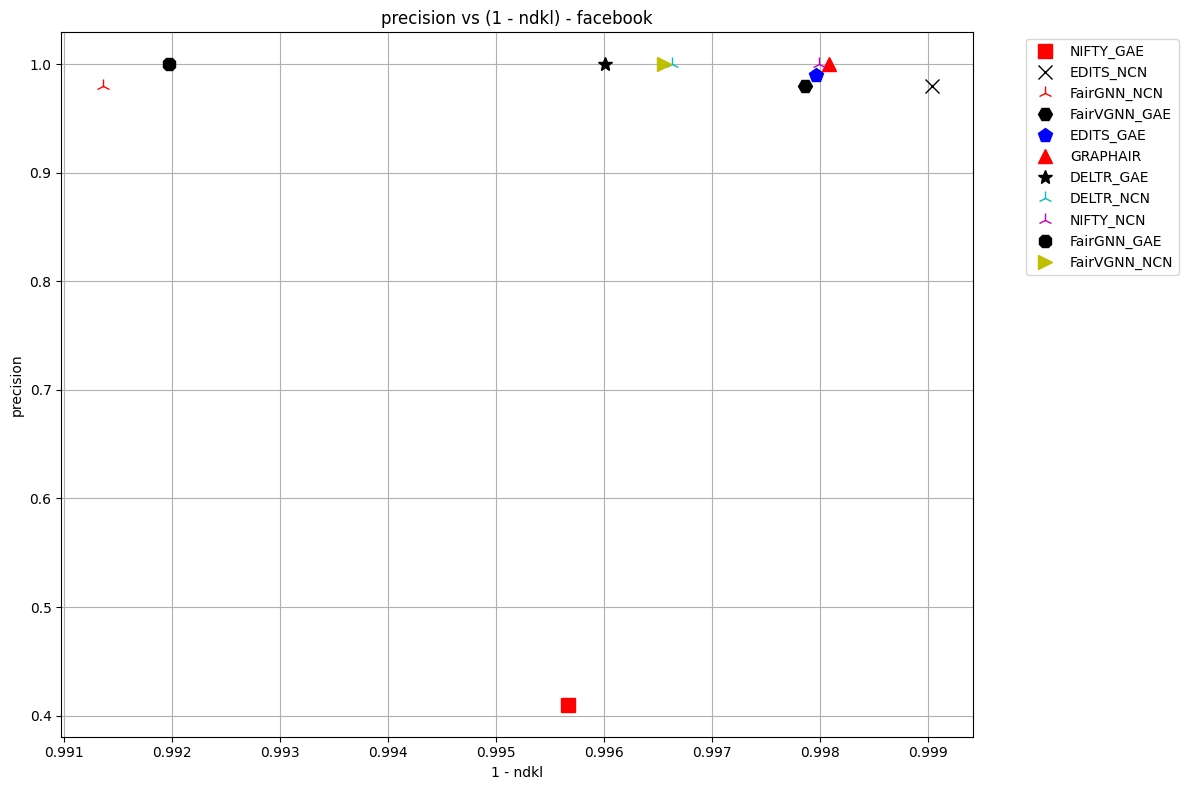

Failed processing styles Labels must be in the format 'model_fairness'


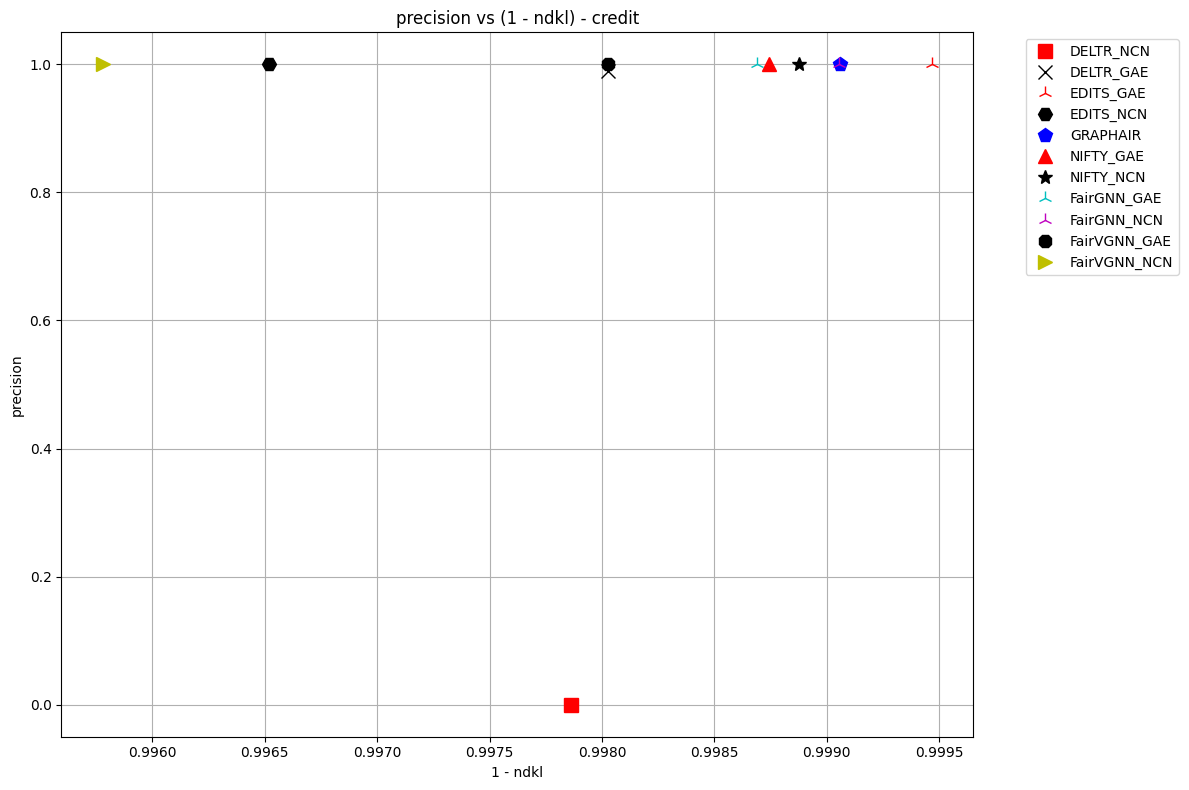

Failed processing styles Labels must be in the format 'model_fairness'


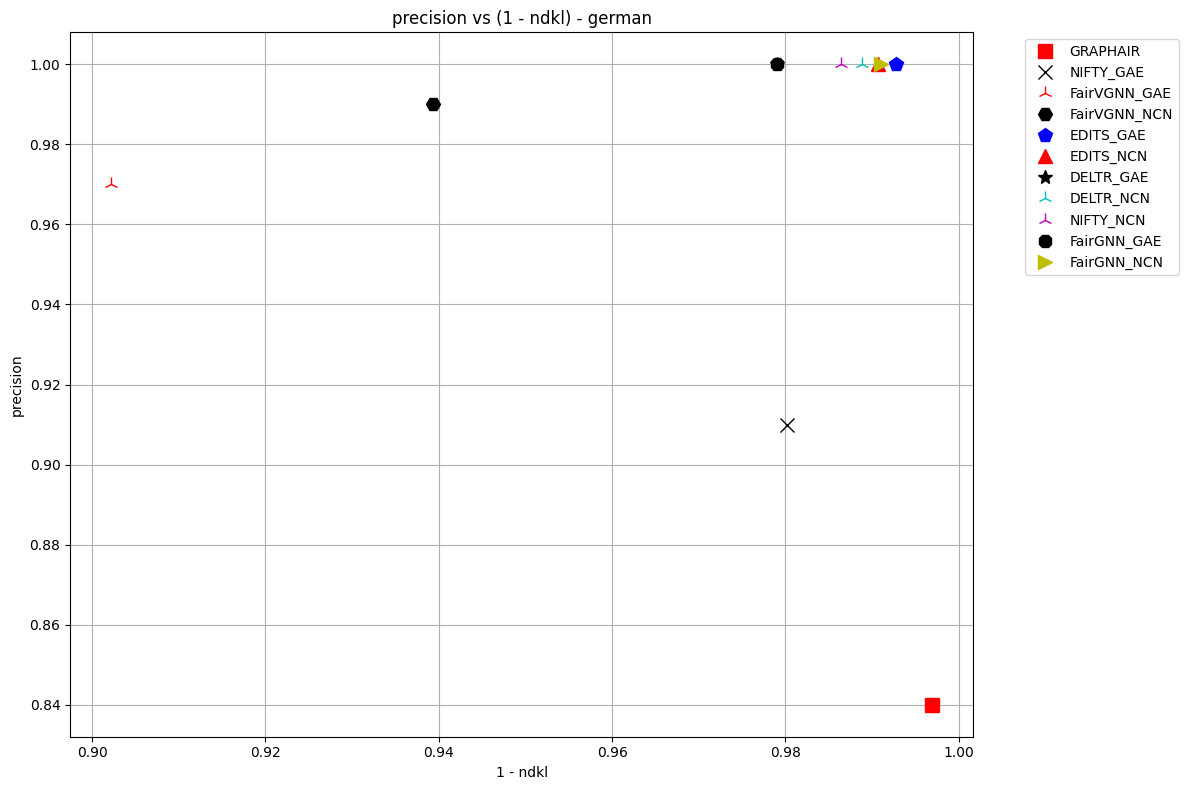

Failed processing styles Labels must be in the format 'model_fairness'


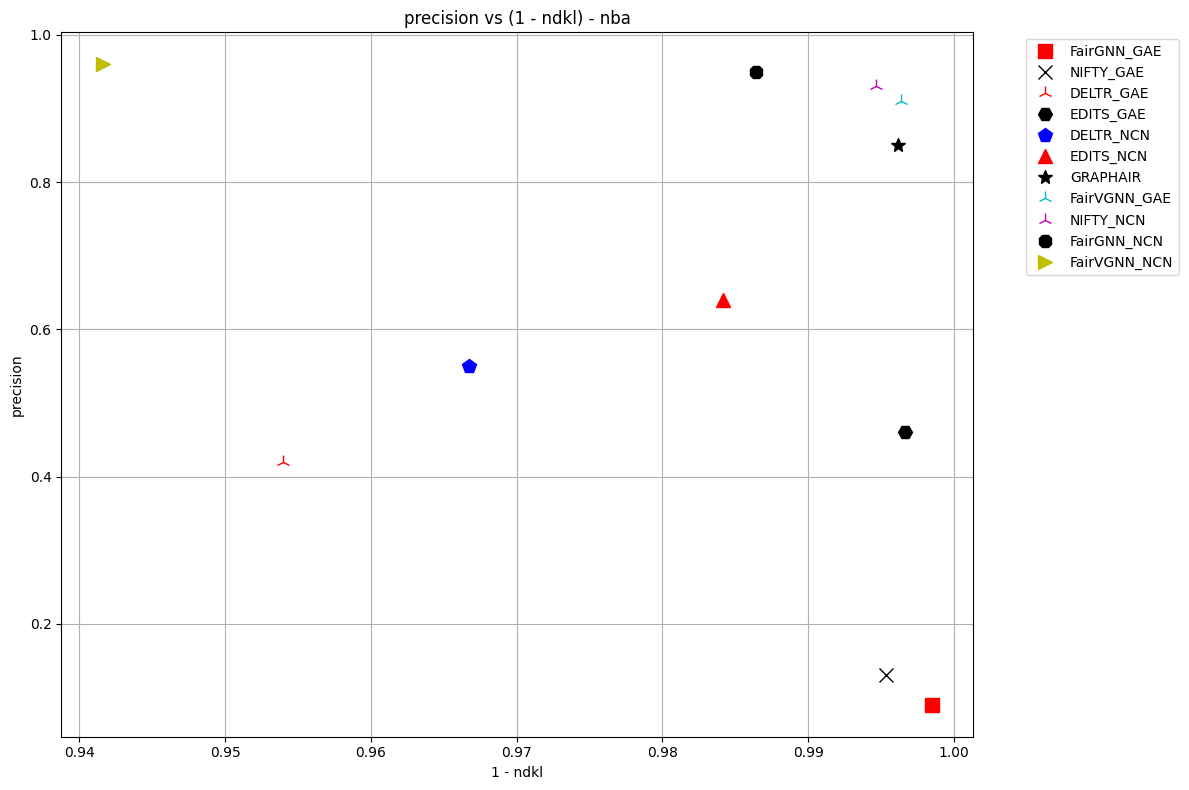

Failed processing styles Labels must be in the format 'model_fairness'


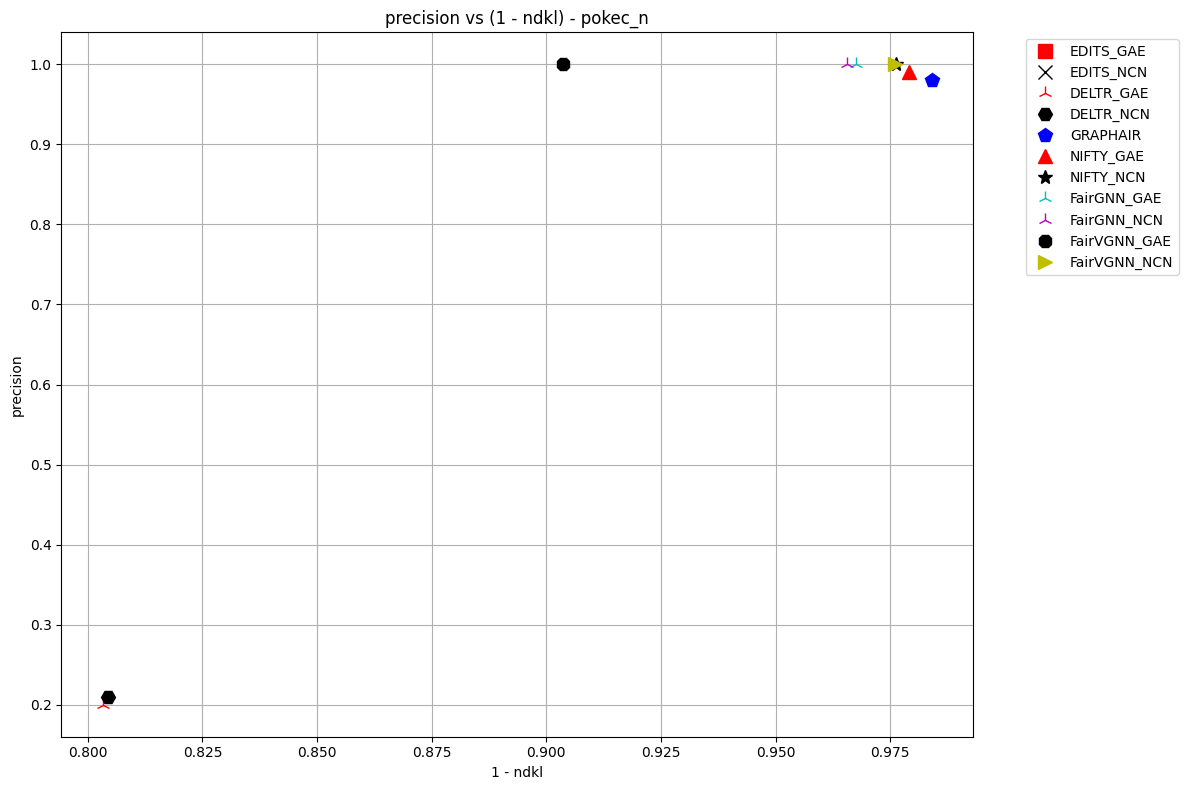

Failed processing styles Labels must be in the format 'model_fairness'


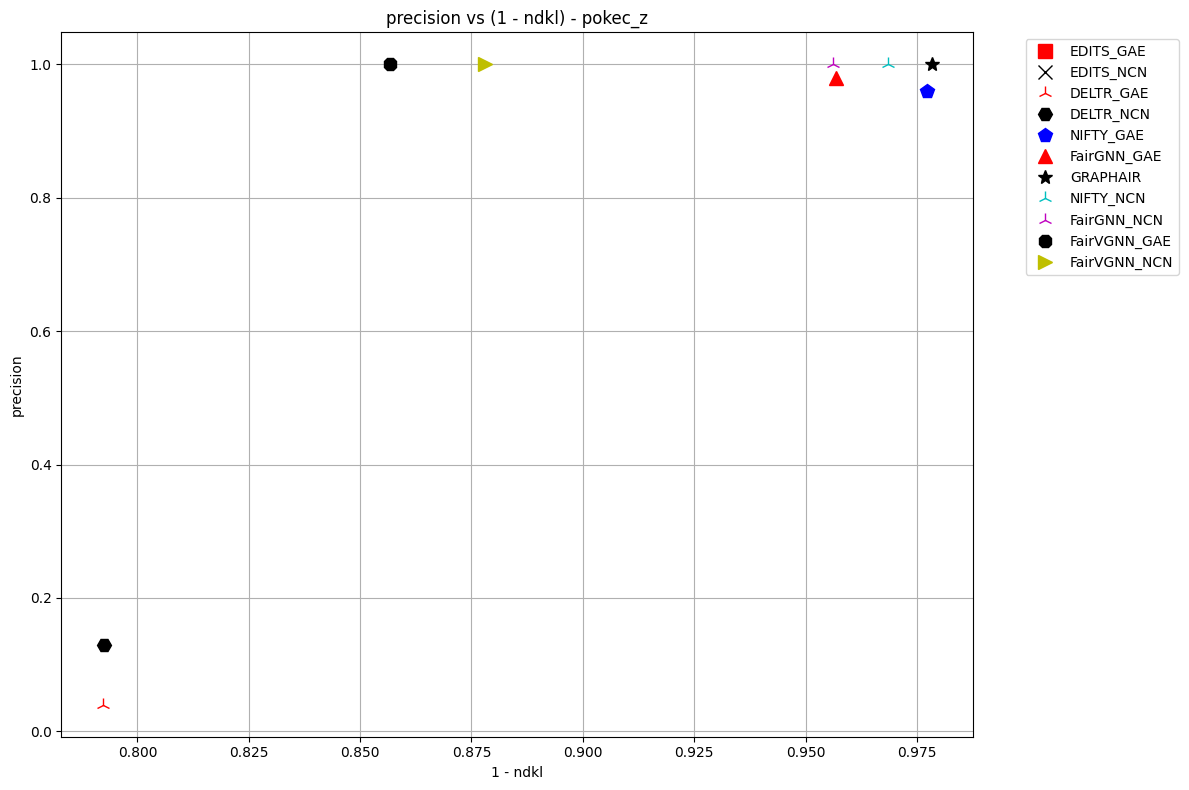

In [77]:



for i in ['facebook', 'credit', 'german', 'nba', 'pokec_n', 'pokec_z']:
    dataset=i
    combined_dict = {key: (1 - dfs['ndkl'].to_dict('index')[dataset][key], dfs['precision'].to_dict('index')[dataset][key]) for key in dfs['precision'].to_dict('index')[dataset]}
    combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
    plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='1 - ndkl', y_axis_label='precision', title=f'precision vs (1 - ndkl) - {dataset}')


Failed processing styles Labels must be in the format 'model_fairness'


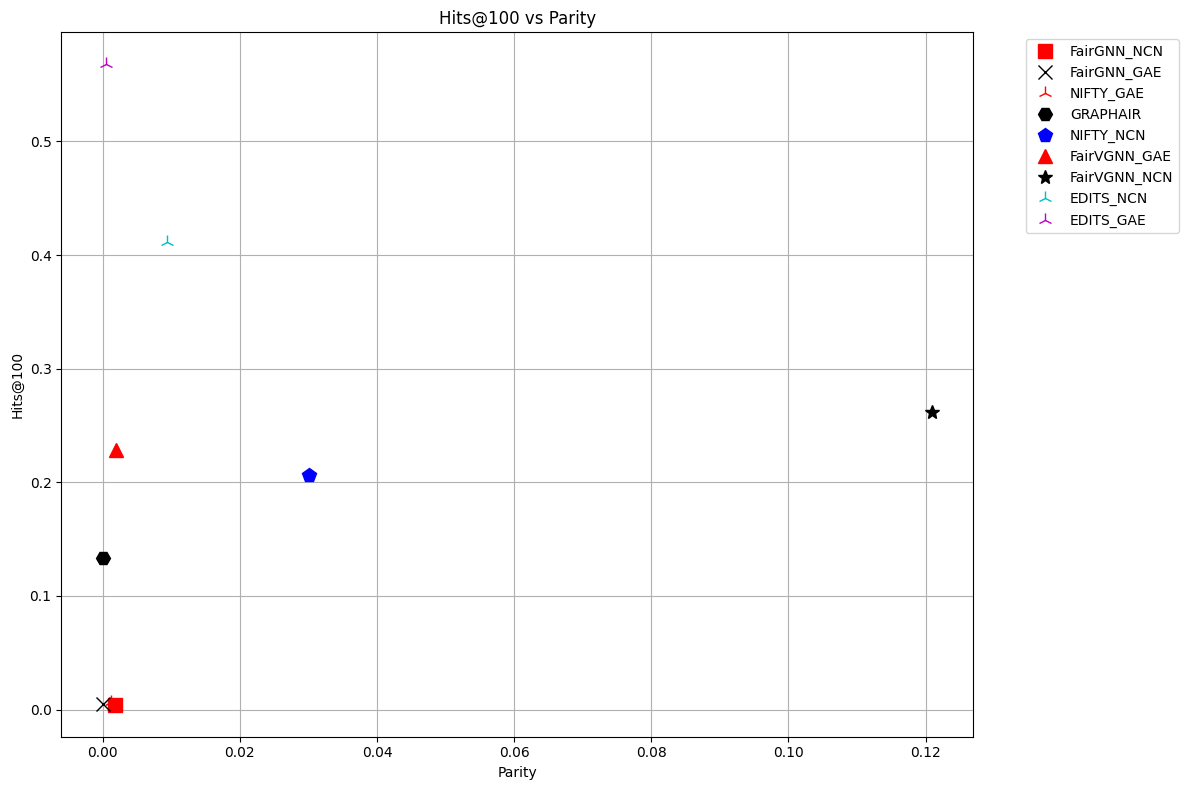

Failed processing styles Labels must be in the format 'model_fairness'


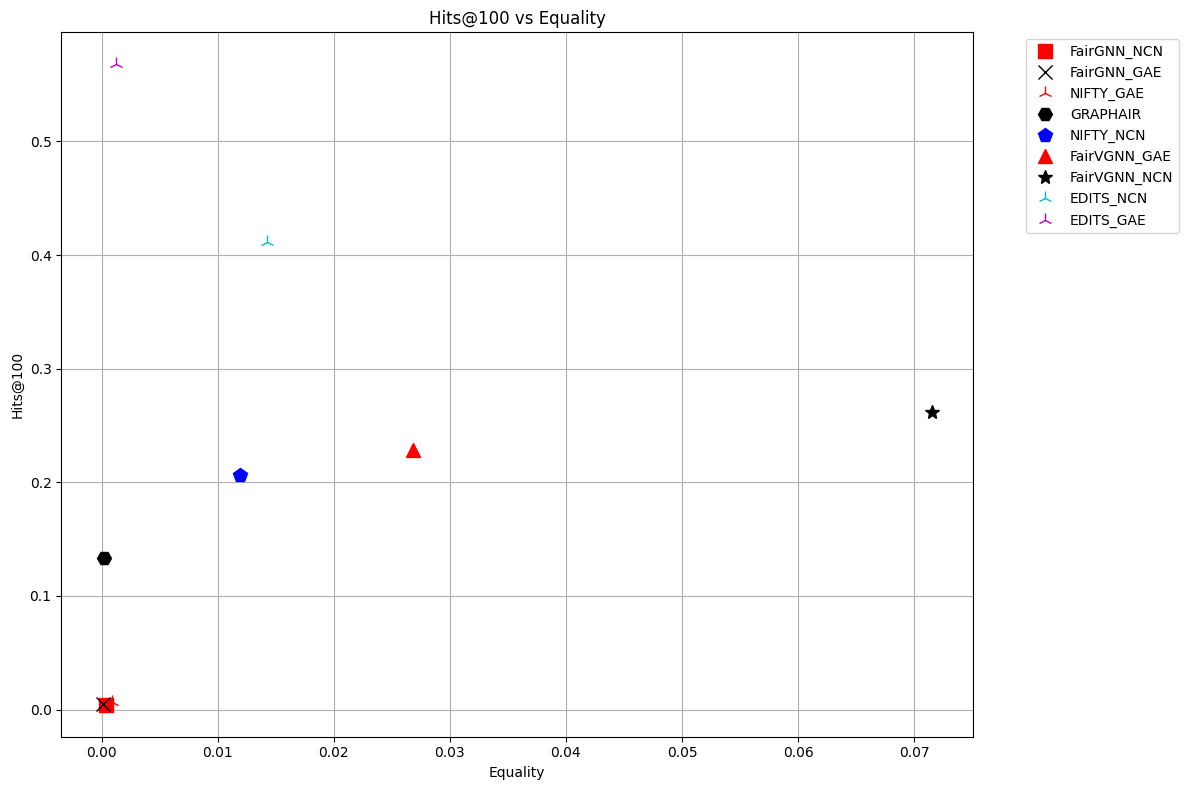

Failed processing styles Labels must be in the format 'model_fairness'


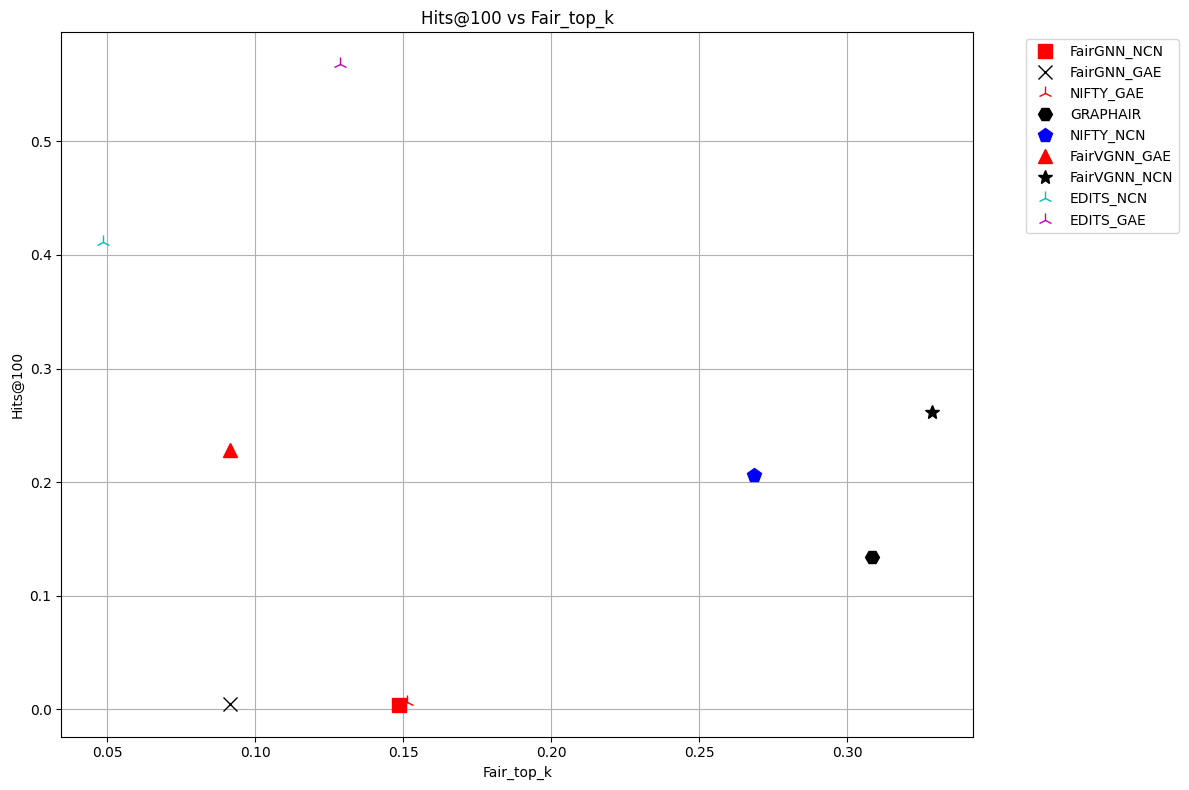

Failed processing styles Labels must be in the format 'model_fairness'


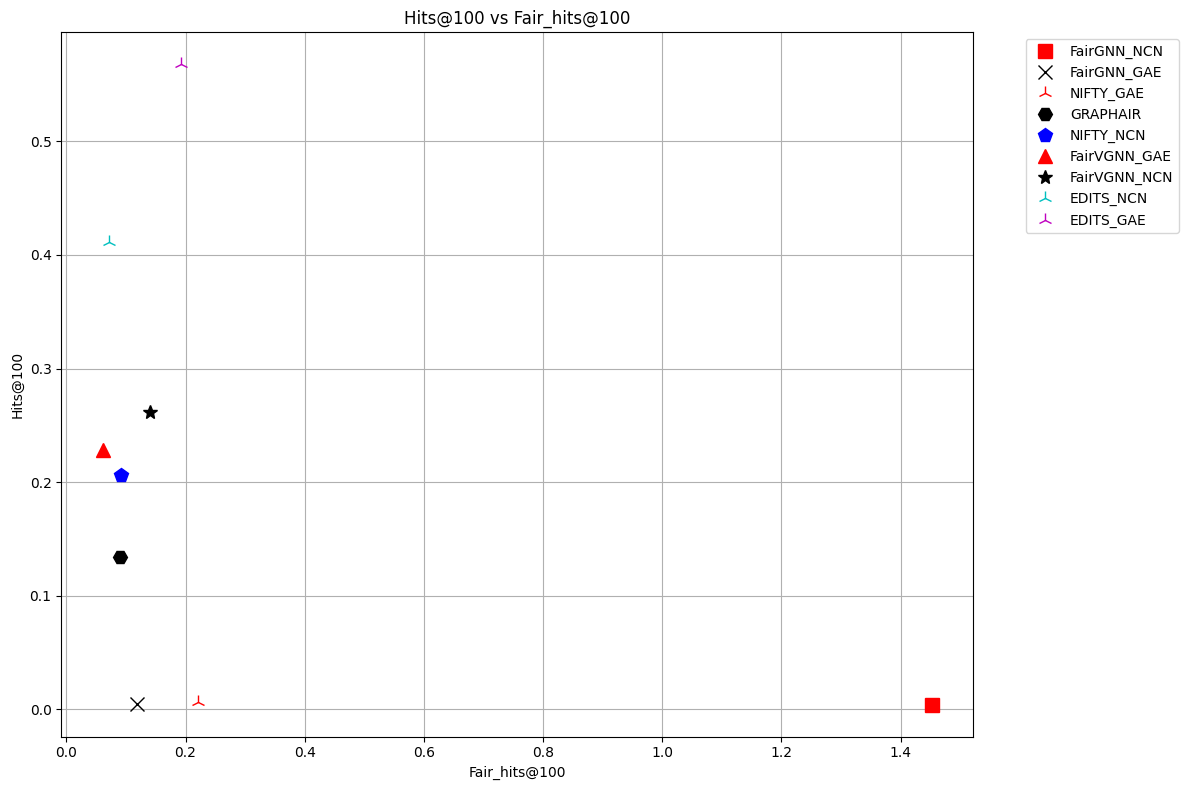

Failed processing styles Labels must be in the format 'model_fairness'


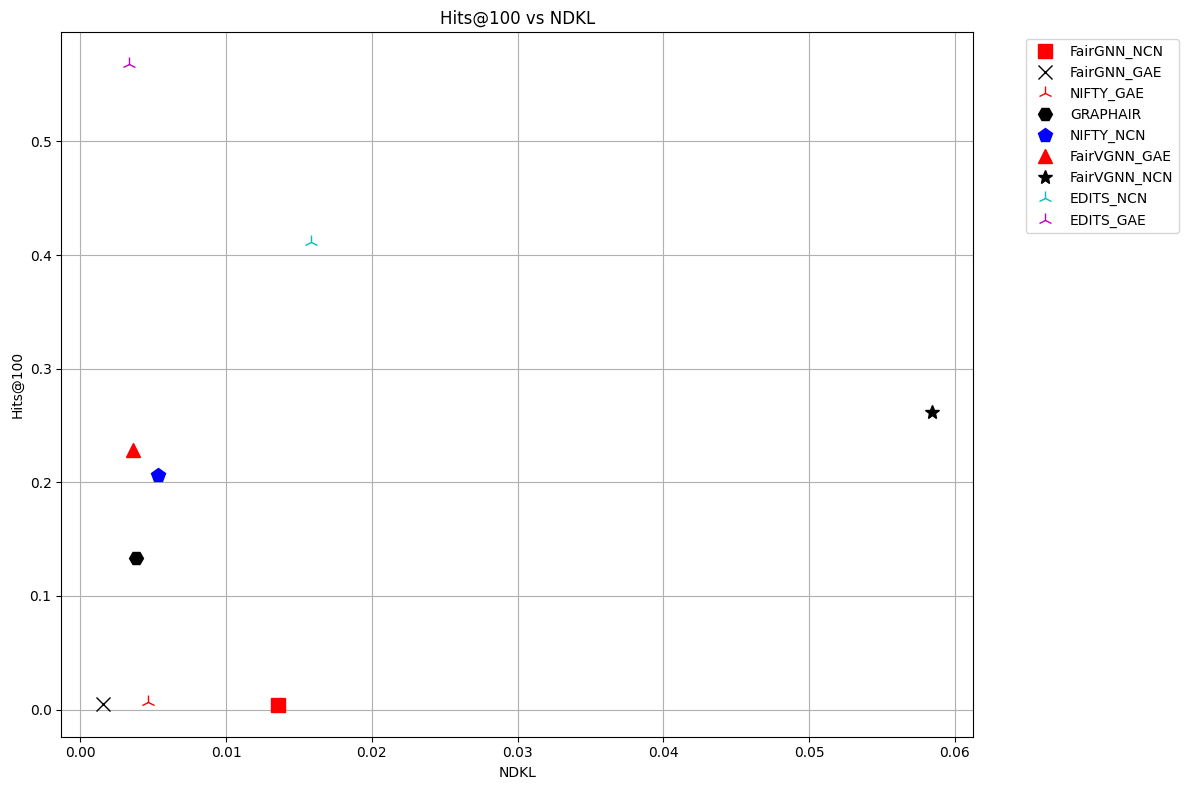

In [144]:
dataset = 3
combined_dict = {key: (dfs[0].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[0].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Parity', y_axis_label='Hits@100', title='Hits@100 vs Parity')
combined_dict = {key: (dfs[1].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[1].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Equality', y_axis_label='Hits@100', title='Hits@100 vs Equality')
combined_dict = {key: (dfs[3].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[3].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Fair_top_k', y_axis_label='Hits@100', title='Hits@100 vs Fair_top_k')
combined_dict = {key: (dfs[4].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[4].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Fair_hits@100', y_axis_label='Hits@100', title='Hits@100 vs Fair_hits@100')
combined_dict = {key: (dfs[5].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[4].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='NDKL', y_axis_label='Hits@100', title='Hits@100 vs NDKL')


Failed processing styles Labels must be in the format 'model_fairness'


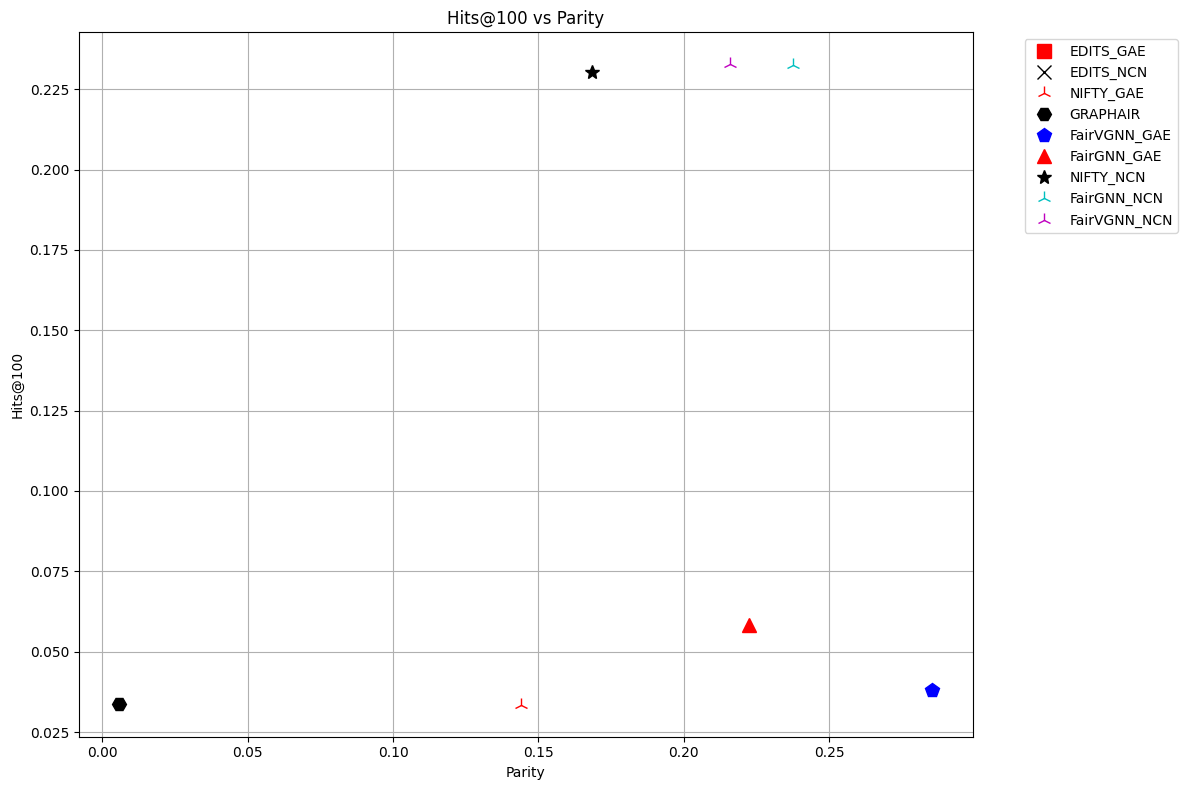

Failed processing styles Labels must be in the format 'model_fairness'


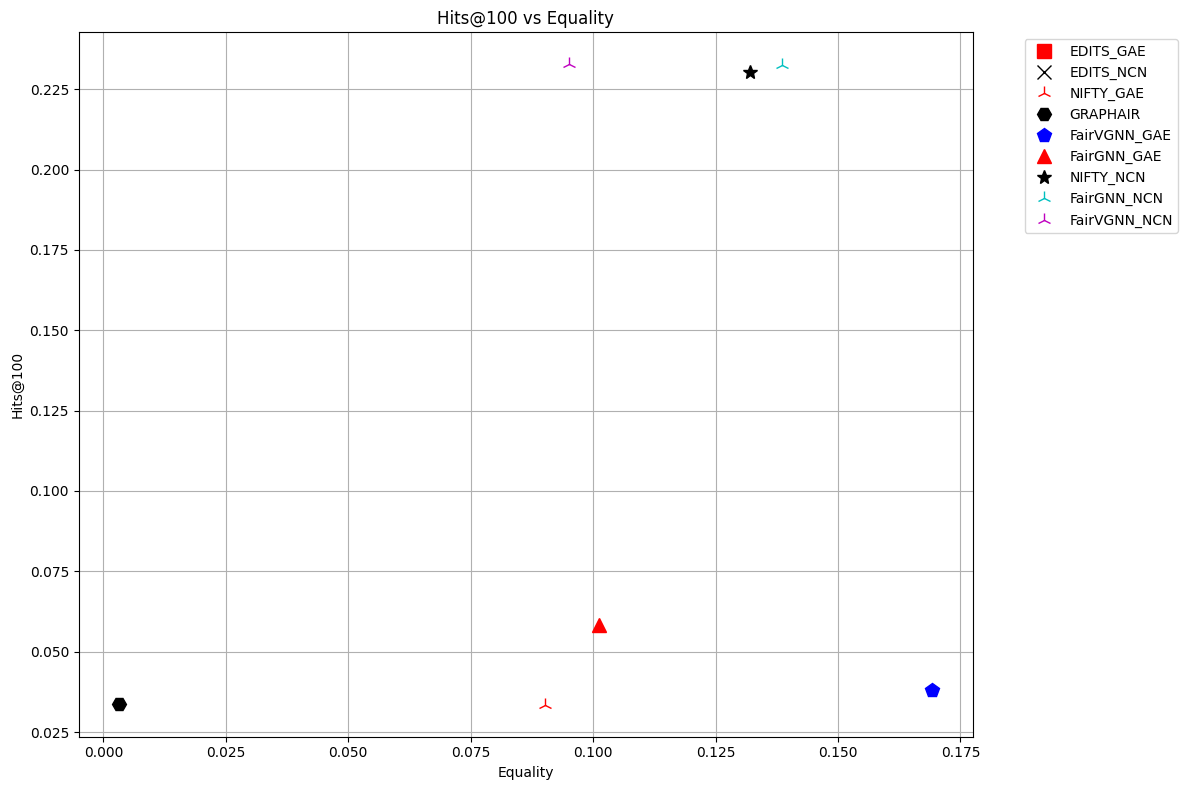

Failed processing styles Labels must be in the format 'model_fairness'


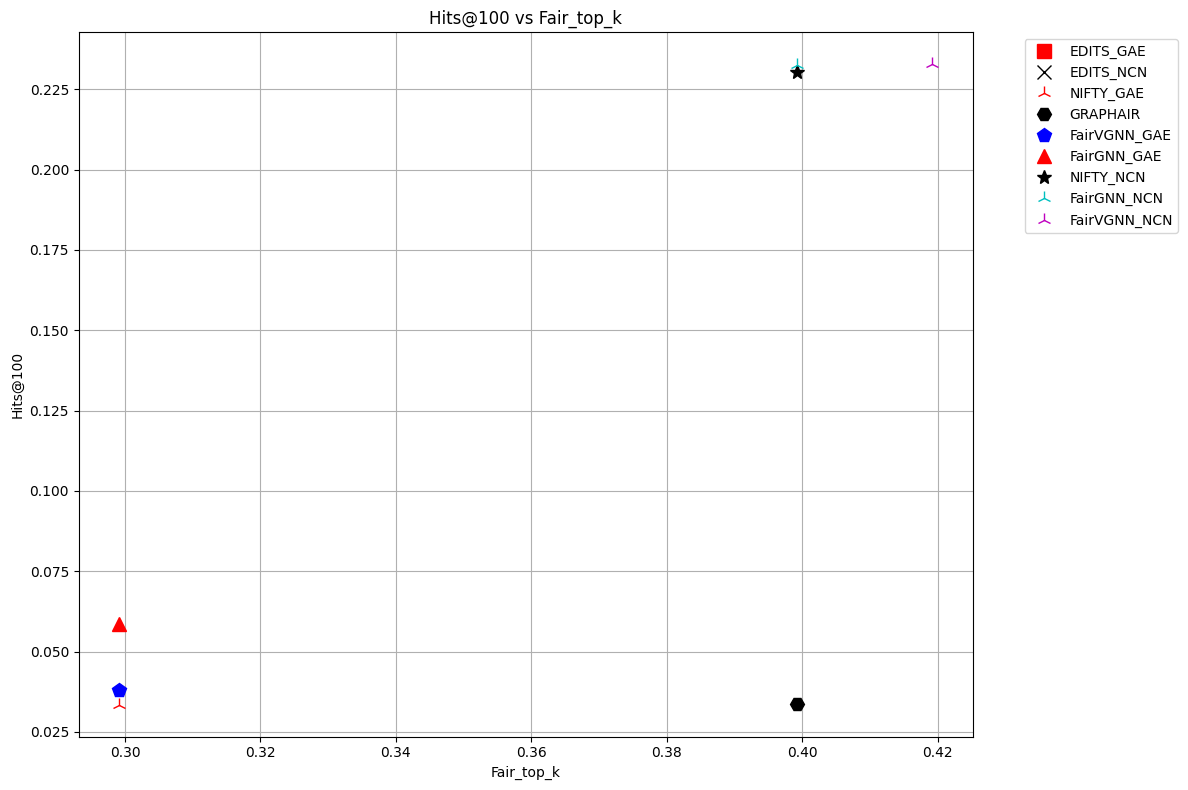

Failed processing styles Labels must be in the format 'model_fairness'


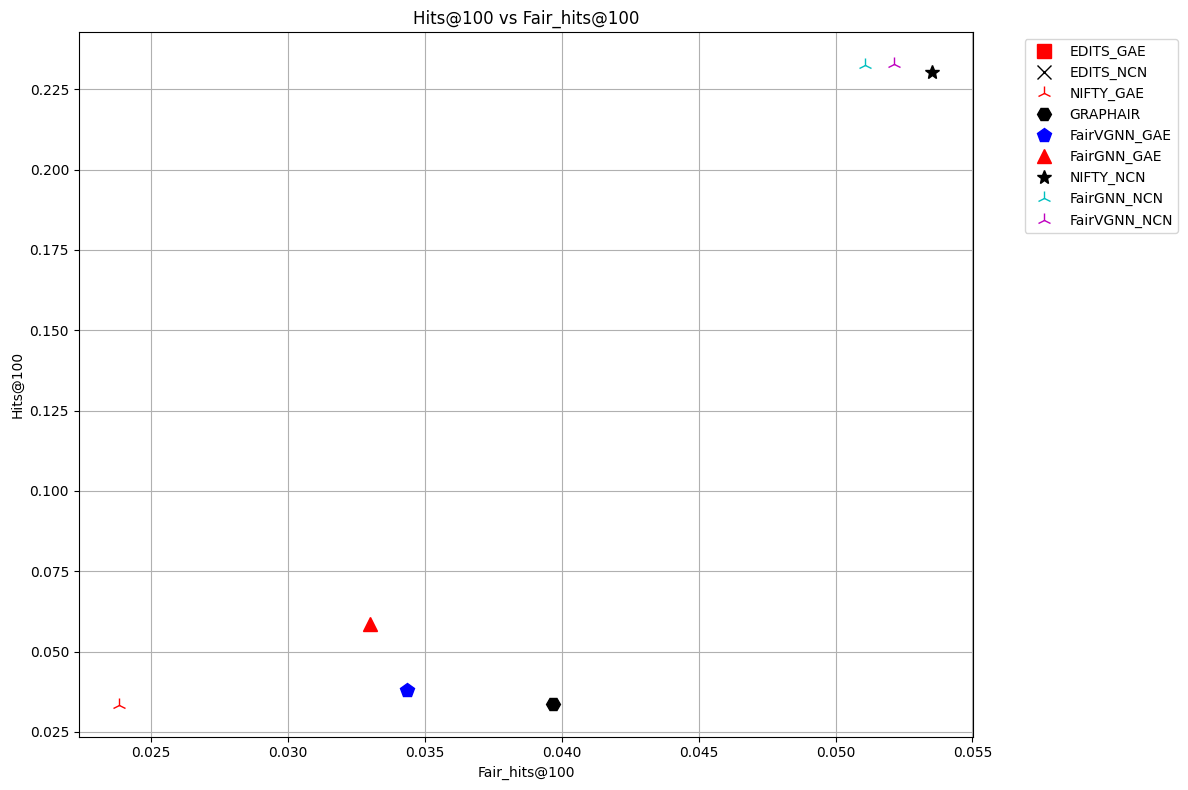

Failed processing styles Labels must be in the format 'model_fairness'


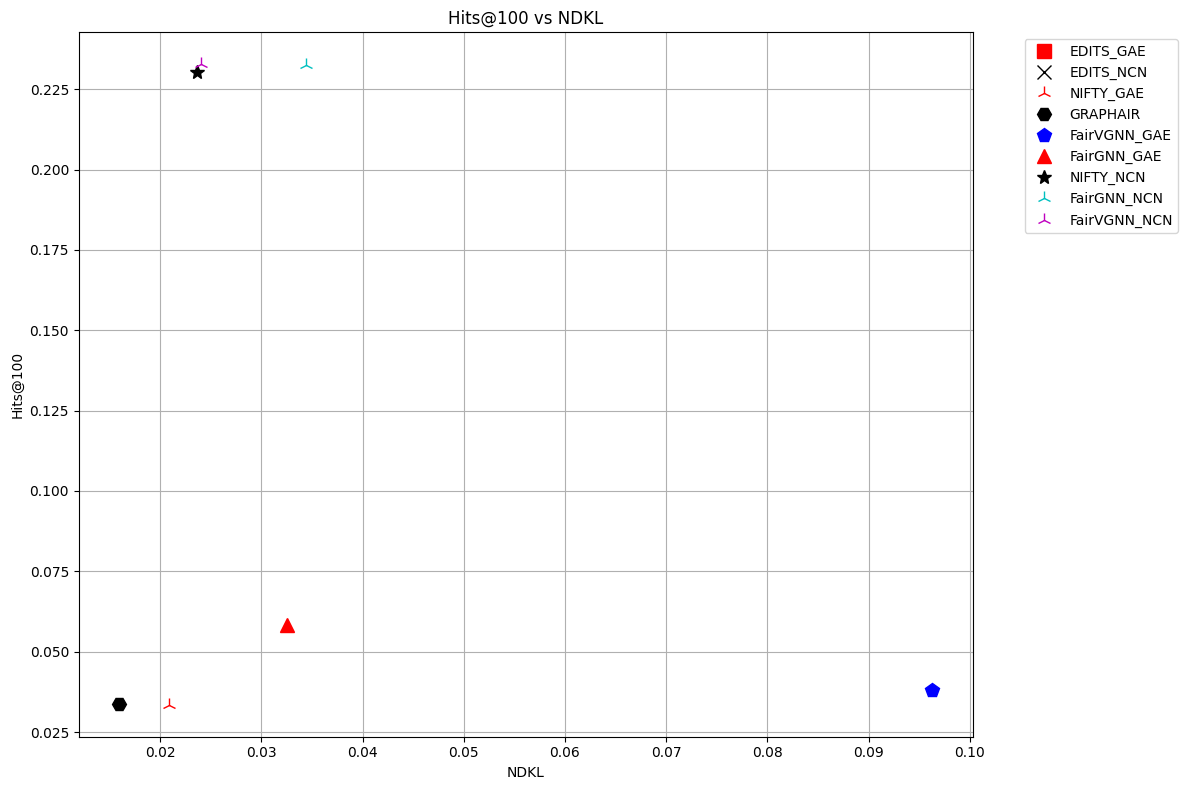

In [147]:
dataset = 4
combined_dict = {key: (dfs[0].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[0].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Parity', y_axis_label='Hits@100', title='Hits@100 vs Parity')
combined_dict = {key: (dfs[1].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[1].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Equality', y_axis_label='Hits@100', title='Hits@100 vs Equality')
combined_dict = {key: (dfs[3].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[3].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Fair_top_k', y_axis_label='Hits@100', title='Hits@100 vs Fair_top_k')
combined_dict = {key: (dfs[4].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[4].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='Fair_hits@100', y_axis_label='Hits@100', title='Hits@100 vs Fair_hits@100')
combined_dict = {key: (dfs[5].to_dict('records')[dataset][key], dfs[2].to_dict('records')[dataset][key]) for key in dfs[4].to_dict('records')[dataset]}
combined_dict = {k: combined_dict[k] for k in sorted(combined_dict, key=lambda k: combined_dict[k][1])}
plot_coordinates(list(combined_dict.values()), list(combined_dict.keys()), x_axis_label='NDKL', y_axis_label='Hits@100', title='Hits@100 vs NDKL')


In [24]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots

plt.style.use(['science','ieee', 'no-latex'])


# Extracting data for plotting
methods = list(stats.keys())
datasets = list(stats[methods[0]].get('GAE', {}).keys())
metrics = ['parity', 'equality', 'hits@100']

# Initialize the plot
fig, ax = plt.subplots(len(metrics), 1, figsize=(10, 15))

bar_width = 0.2  # Width of the bars
index = np.arange(len(datasets))  # The label locations

for i, metric in enumerate(metrics):
    for j, method in enumerate(methods):
        values = [stats[method].get('GAE', {}).get(dataset, {}).get(metric, 0) for dataset in datasets]
        ax[i].bar(index + j * bar_width, values, bar_width, label=method)
    
    ax[i].set_title(metric)
    ax[i].set_ylabel(metric)
    ax[i].set_xticks(index + bar_width * (len(methods) - 1) / 2)
    ax[i].set_xticklabels(datasets)
    ax[i].legend()

plt.xlabel('Datasets')
plt.tight_layout()
plt.show()


KeyError: 'NCN'

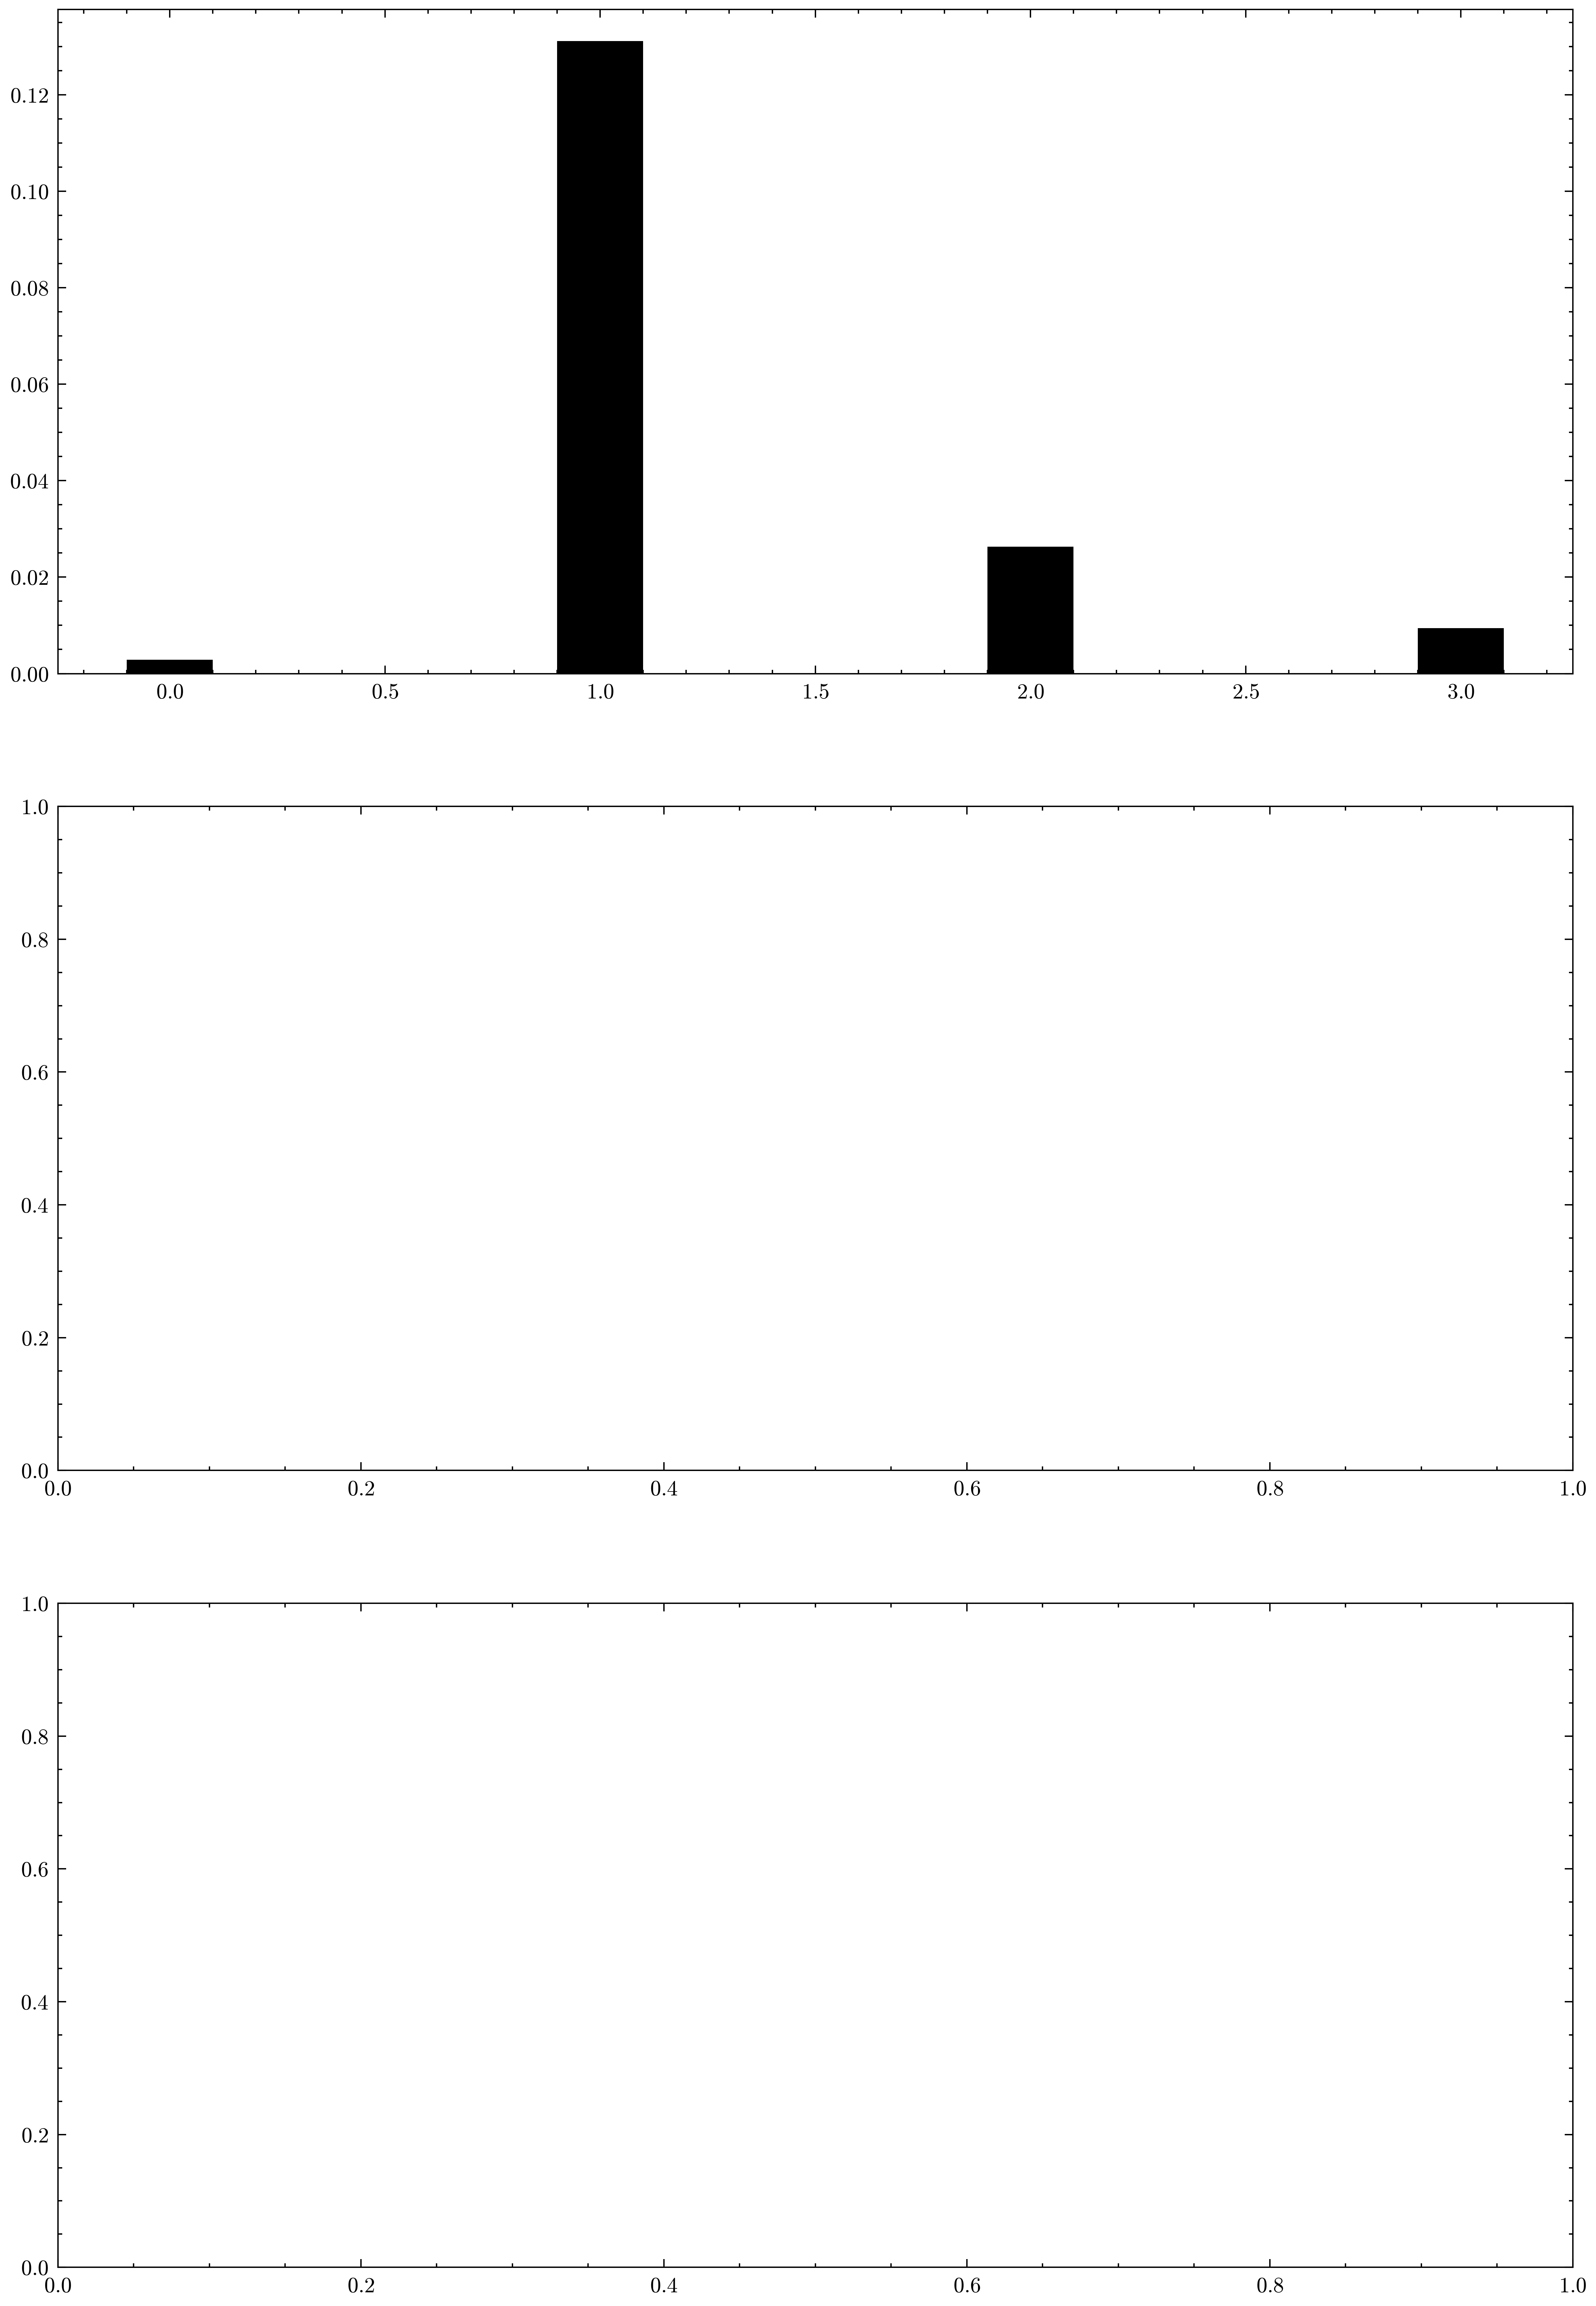

In [29]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots

plt.style.use(['science','ieee', 'no-latex'])


# Extracting data for plotting
methods = list(stats.keys())
datasets = list(stats[methods[0]]['NCN'].keys())
metrics = ['parity', 'equality', 'hits@100']

# Initialize the plot
fig, ax = plt.subplots(len(metrics), 1, figsize=(10, 15))

bar_width = 0.2  # Width of the bars
index = np.arange(len(datasets))  # The label locations

for i, metric in enumerate(metrics):
    for j, method in enumerate(methods):
        values = [stats[method]['NCN'][dataset][metric] for dataset in datasets]
        ax[i].bar(index + j * bar_width, values, bar_width, label=method)
    
    ax[i].set_title(metric)
    ax[i].set_ylabel(metric)
    ax[i].set_xticks(index + bar_width * (len(methods) - 1) / 2)
    ax[i].set_xticklabels(datasets)
    ax[i].legend()

plt.xlabel('Datasets')
plt.tight_layout()
plt.show()